# Notebook 02 - Exploratory Data Analysis

This notebook explores the clean table produced by Notebook 01. Its purpose is
to *see* the structure that Notebook 03 will then test formally. We move from
group composition, to the two central patterns of the study - the dose-response
curve (RQ1) and the use-case comparison (RQ2) - to the role of prompt skill
(RQ3), substitution (RQ4), wellbeing (RQ5), and finally the correlation
structure of the whole table.

Every figure uses the shared colour-vision-safe visual system. Sequential
encodings use one blue ramp; the diverging encoding uses blue-to-red about a
neutral midpoint; categorical series keep a fixed hue order.

In [1]:
# Standard library
import warnings
from pathlib import Path

# Scientific stack
import numpy as np
import pandas as pd

# Visualisation
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Project paths (notebooks live in notebooks/, data one level up)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_CSV = ROOT / "data" / "ai_student_impact_dataset (1).csv"
PROC_DIR = ROOT / "data" / "processed"
PROC_CSV = PROC_DIR / "students_clean.csv"
FIG_DIR = ROOT / "reports" / "figures"
PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("pandas", pd.__version__, "| numpy", np.__version__)


pandas 3.0.3 | numpy 2.5.1


In [2]:
# ----------------------------------------------------------------------
# Visual system: one colour-vision-safe palette used across every figure.
# Categorical hues are assigned in a fixed order (never cycled); sequential
# encodings use a single-hue blue ramp; diverging encodings use blue<->red
# with a neutral midpoint. Grids are recessive and marks are thin.
# ----------------------------------------------------------------------
PALETTE = {
    "blue":    "#2a78d6", "aqua":   "#1baf7a", "yellow":  "#eda100",
    "green":   "#008300", "violet": "#4a3aa7", "red":     "#e34948",
    "magenta": "#e87ba4", "orange": "#eb6834",
}
CAT = list(PALETTE.values())

INK, INK_SOFT, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
GOOD, WARN, SERIOUS, CRITICAL = "#0ca30c", "#fab219", "#ec835a", "#d03b3b"

# Ordered status colours for Low / Medium / High categories
RISK_COLORS = {"Low": GOOD, "Medium": WARN, "High": CRITICAL}

# Single-hue sequential ramp (magnitude) and blue<->red diverging ramp (polarity)
_SEQ = ["#eaf2fd", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
SEQ_BLUE = LinearSegmentedColormap.from_list("seq_blue", _SEQ)
DIVERGING = LinearSegmentedColormap.from_list(
    "blue_red", ["#184f95", "#6da7ec", "#f0efec", "#e88a89", "#c0332f"]
)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "figure.dpi": 110, "savefig.dpi": 150,
    "font.size": 11, "font.family": "sans-serif",
    "axes.edgecolor": BASELINE, "axes.linewidth": 1.0,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 12, "axes.labelcolor": INK_SOFT, "axes.labelsize": 10.5,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "legend.frameon": False, "legend.fontsize": 10,
    "lines.linewidth": 2.0, "lines.markersize": 7,
})

def style_axis(ax):
    """Recessive grid on y only; clean baseline."""
    ax.grid(axis="x", visible=False)
    ax.grid(axis="y", visible=True)
    for s in ("left",):
        ax.spines[s].set_color(BASELINE)
    return ax

sns.set_style("white")
print("Visual system ready:", len(CAT), "categorical hues.")


Visual system ready: 8 categorical hues.


## Load the processed table

We restore the ordered categorical bands (CSV does not preserve category order)
so the dose-response axis reads in the correct sequence.

In [3]:
df = pd.read_csv(PROC_CSV)
band_labels = ["None/Minimal (0-2h)", "Light (2-8h)", "Moderate (8-15h)", "Heavy (15h+)"]
df["GenAI_Intensity_Band"] = pd.Categorical(df["GenAI_Intensity_Band"], categories=band_labels, ordered=True)
skill_order = ["Beginner", "Intermediate", "Advanced"]
df["Prompt_Engineering_Skill"] = pd.Categorical(df["Prompt_Engineering_Skill"], categories=skill_order, ordered=True)
print(f"Loaded {df.shape[0]:,} rows.")
df[["GPA_Delta", "Skill_Retention_Score", "Weekly_GenAI_Hours", "GenAI_Intensity_Band"]].head()

Loaded 50,000 rows.


,GPA_Delta,Skill_Retention_Score,Weekly_GenAI_Hours,GenAI_Intensity_Band
0,-0.025,86.44,23.31,Heavy (15h+)
1,-0.125,69.39,1.12,None/Minimal (0-2h)
2,0.101,73.93,21.26,Heavy (15h+)
3,0.211,63.58,1.82,None/Minimal (0-2h)
4,0.163,100.00,9.29,Moderate (8-15h)


## 1. Outcomes across disciplines

A first orientation: do the two continuous outcomes - grade improvement and skill
retention - differ by field of study? We use half-violins to show the full
distribution, not just a mean.

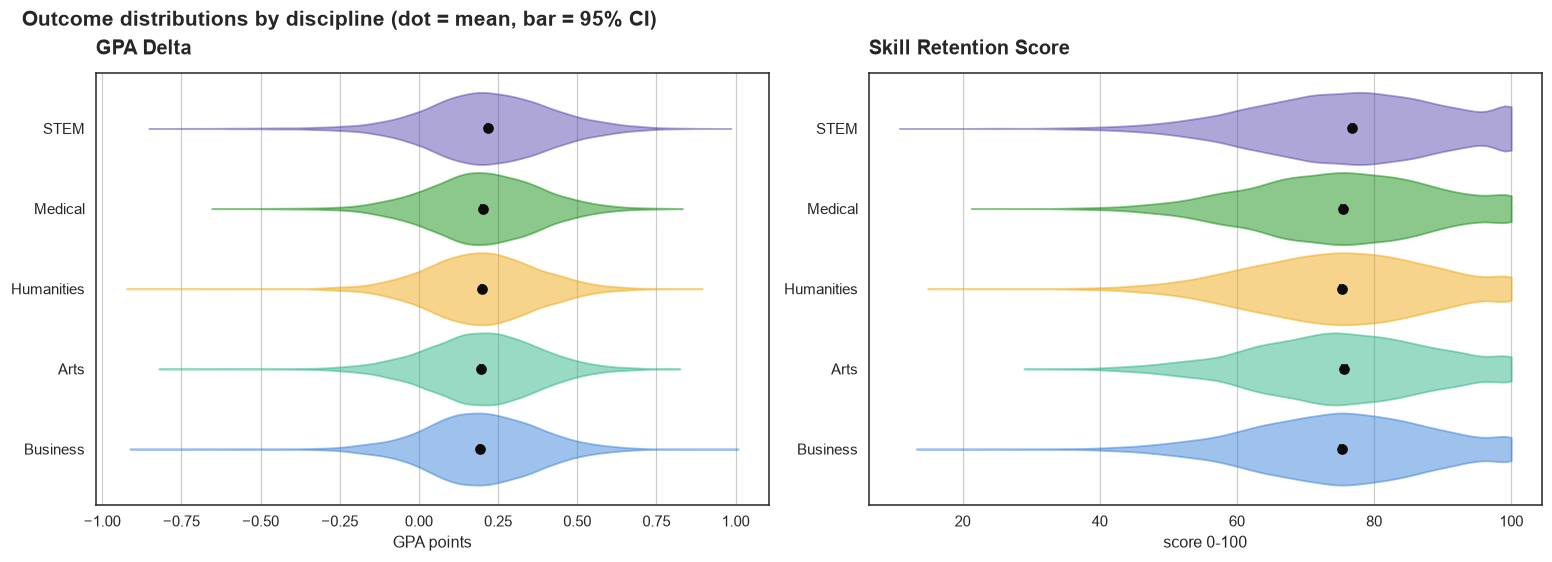

In [4]:
def ci95(s):
    s = s.dropna(); m = s.mean(); h = 1.96 * s.std(ddof=1) / np.sqrt(len(s))
    return m, h

majors = df.groupby("Major_Category")["GPA_Delta"].mean().sort_values().index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for ax, (col, unit) in zip(axes, [("GPA_Delta", "GPA points"), ("Skill_Retention_Score", "score 0-100")]):
    parts = ax.violinplot([df.loc[df.Major_Category == m, col].values for m in majors],
                          showmeans=False, showextrema=False, vert=False, widths=0.9)
    for i, b in enumerate(parts["bodies"]):
        b.set(facecolor=CAT[i % len(CAT)], alpha=0.45, edgecolor=CAT[i % len(CAT)], linewidth=1.2)
    for i, m in enumerate(majors):
        mean, h = ci95(df.loc[df.Major_Category == m, col])
        ax.errorbar(mean, i + 1, xerr=h, fmt="o", color=INK, ms=6, capsize=3, zorder=5)
    ax.set_yticks(range(1, len(majors) + 1)); ax.set_yticklabels(majors)
    ax.set_title(col.replace("_", " ")); ax.set_xlabel(unit)
    ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
fig.suptitle("Outcome distributions by discipline (dot = mean, bar = 95% CI)",
             fontsize=14, fontweight="bold", x=0.01, ha="left")
plt.show()

**Reading it.** Disciplinary differences in both outcomes are modest -
the distributions overlap heavily. Field of study is not where the action is.
This is the first hint that behaviour, not demographics, drives the outcomes.

## 2. The dose-response curve (RQ1)

The central question of the intensity debate: is more GenAI use better, worse, or
neither? We plot mean skill retention and mean grade improvement across ordered
usage bands, each with a 95% confidence interval. A monotonic line would support
the "more is better/worse" framing; a peak would reject it.

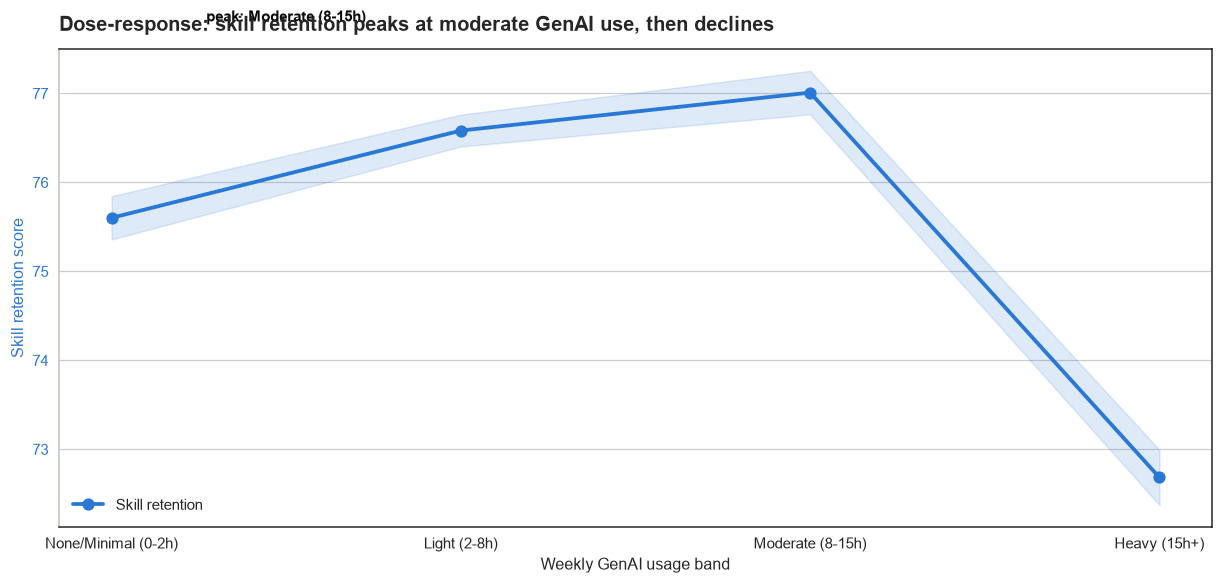

                       mean  count    ci
GenAI_Intensity_Band                    
None/Minimal (0-2h)   75.60  10740  0.24
Light (2-8h)          76.58  20022  0.18
Moderate (8-15h)      77.01  10704  0.24
Heavy (15h+)          72.68   8534  0.31


In [5]:
fig, ax1 = plt.subplots(figsize=(11, 5.2), constrained_layout=True)
bands = band_labels
x = np.arange(len(bands))
g = df.groupby("GenAI_Intensity_Band", observed=True)

ret = g["Skill_Retention_Score"].agg(["mean", "count", "std"])
ret["ci"] = 1.96 * ret["std"] / np.sqrt(ret["count"])
ax1.plot(x, ret["mean"], "-o", color=PALETTE["blue"], lw=2.5, label="Skill retention")
ax1.fill_between(x, ret["mean"] - ret["ci"], ret["mean"] + ret["ci"], color=PALETTE["blue"], alpha=0.15)
ax1.set_ylabel("Skill retention score", color=PALETTE["blue"])
ax1.tick_params(axis="y", labelcolor=PALETTE["blue"])

peak = ret["mean"].idxmax()
ax1.annotate(f"peak: {peak}", xy=(list(ret.index).index(peak), ret["mean"].max()),
             xytext=(0.5, ret["mean"].max() + 0.8), fontsize=10, color=INK,
             fontweight="bold", ha="center")
ax1.set_xticks(x); ax1.set_xticklabels(bands, fontsize=9.5)
ax1.set_title("Dose-response: skill retention peaks at moderate GenAI use, then declines")
ax1.set_xlabel("Weekly GenAI usage band"); style_axis(ax1)
ax1.legend(loc="lower left")
plt.show()
print(ret[["mean", "count", "ci"]].round(2))

**Reading it.** The relationship is **non-monotonic**. Skill retention
rises from minimal to light/moderate use and then falls for heavy users - an
inverted-U. This is the study's first substantive result: *there is a moderate-use
optimum*, and framing the debate as "more versus less" misses it. Notebook 03
tests the curvature formally with a quadratic term.

## 3. Purpose matters more than amount (RQ2)

If intensity is not the whole story, *what students use GenAI for* should
separate outcomes. We compare grade improvement across primary use cases, with
the cognitive-offloading pattern (direct answer generation) highlighted.

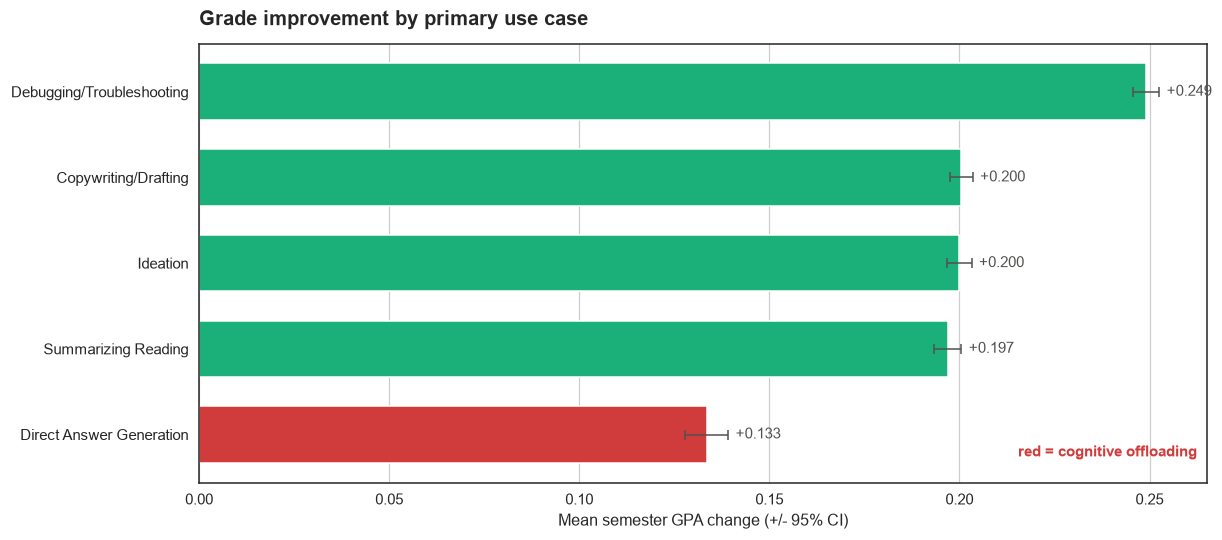

In [6]:
uc = df.groupby("Primary_Use_Case")["GPA_Delta"].agg(["mean", "count", "std"]).sort_values("mean")
uc["ci"] = 1.96 * uc["std"] / np.sqrt(uc["count"])
colors = [CRITICAL if u == "Direct_Answer_Generation" else PALETTE["aqua"] for u in uc.index]

fig, ax = plt.subplots(figsize=(11, 4.8), constrained_layout=True)
ax.barh(range(len(uc)), uc["mean"], xerr=uc["ci"], color=colors, height=0.66,
        error_kw=dict(ecolor=INK_SOFT, capsize=3, lw=1))
for i, (m, ci) in enumerate(zip(uc["mean"], uc["ci"])):
    ax.text(m + ci + 0.002, i, f"{m:+.3f}", va="center", fontsize=9.5, color=INK_SOFT)
ax.set_yticks(range(len(uc))); ax.set_yticklabels([u.replace("_", " ") for u in uc.index])
ax.set_xlabel("Mean semester GPA change (+/- 95% CI)")
ax.set_title("Grade improvement by primary use case")
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.text(0.99, 0.06, "red = cognitive offloading", transform=ax.transAxes,
        ha="right", color=CRITICAL, fontsize=9.5, fontweight="bold")
plt.show()

**Reading it.** Use case separates outcomes more cleanly than intensity
did. Analytic and generative uses - debugging, ideation, drafting - are
associated with the largest grade gains, while **direct answer generation**, the
purest form of cognitive offloading, sits at the bottom. Same tool, different
outcome, depending on the cognitive work the student keeps for themselves.

## 4. Prompt-engineering skill and retention (RQ3)

Competence with the tool is itself a usage pattern. We look at skill retention
across the three prompt-skill levels, and split by intensity band to check the
pattern is not just heavy users being more skilled.

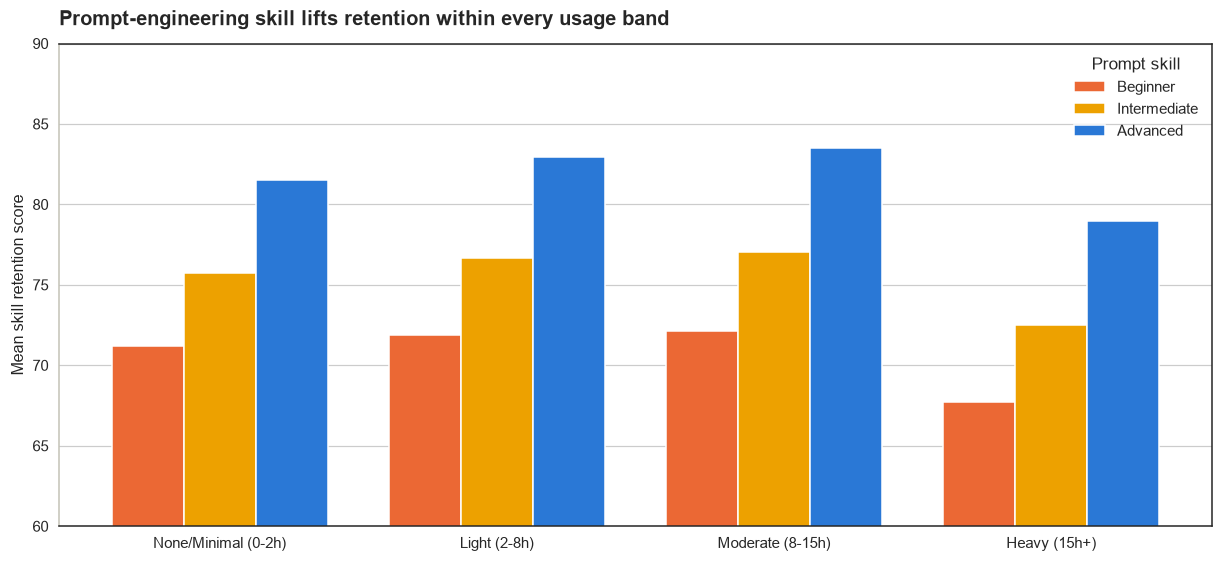

In [7]:
piv = df.pivot_table(index="GenAI_Intensity_Band", columns="Prompt_Engineering_Skill",
                     values="Skill_Retention_Score", aggfunc="mean", observed=True)
piv = piv[skill_order].reindex(band_labels)
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
skill_hues = {"Beginner": PALETTE["orange"], "Intermediate": PALETTE["yellow"], "Advanced": PALETTE["blue"]}
xb = np.arange(len(band_labels)); w = 0.26
for j, sk in enumerate(skill_order):
    ax.bar(xb + (j - 1) * w, piv[sk].values, width=w, color=skill_hues[sk], label=sk)
ax.set_xticks(xb); ax.set_xticklabels(band_labels, fontsize=9.5)
ax.set_ylabel("Mean skill retention score"); ax.set_ylim(60, 90)
ax.set_title("Prompt-engineering skill lifts retention within every usage band")
ax.legend(title="Prompt skill", loc="upper right"); style_axis(ax)
plt.show()

**Reading it.** Within *every* intensity band, advanced prompt users retain
more skill than beginners - the gap is not an artefact of how much they use the
tool. Notably, advanced users hold up far better under heavy use: skill, not
abstinence, is what protects the heavy-use group.

## 5. Substitution or complement? (RQ4)

Does GenAI replace study, or sit alongside it? We bin the two-dimensional space
of weekly GenAI hours by traditional study hours and colour each cell by mean
grade improvement - a heatmap using the single-hue sequential ramp.

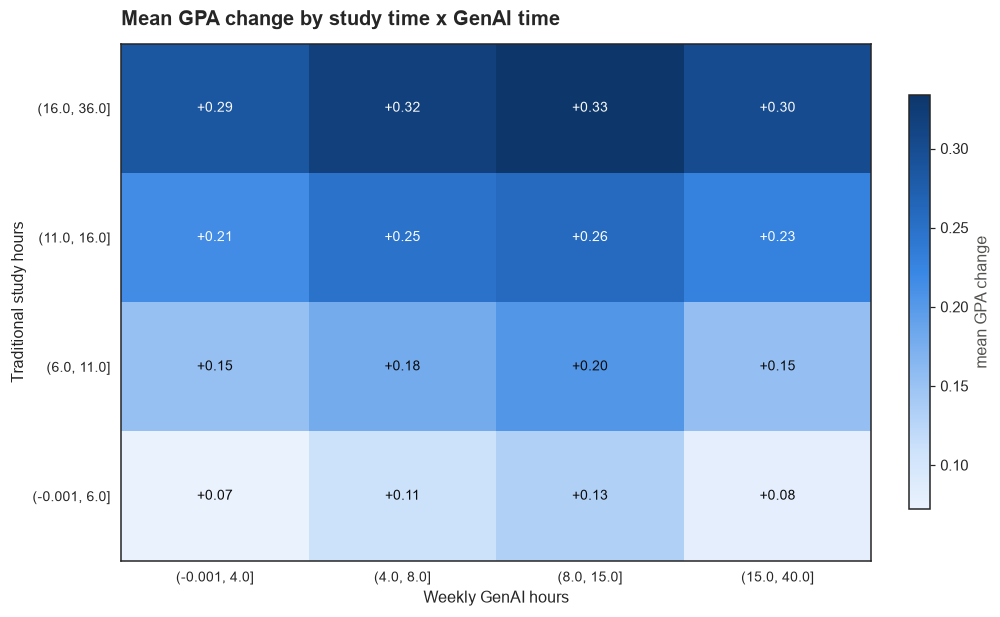

In [8]:
df["_gen_bin"] = pd.cut(df["Weekly_GenAI_Hours"], [0, 4, 8, 15, 40], include_lowest=True)
df["_std_bin"] = pd.cut(df["Traditional_Study_Hours"], [0, 6, 11, 16, 36], include_lowest=True)
hm = df.pivot_table(index="_std_bin", columns="_gen_bin", values="GPA_Delta", aggfunc="mean", observed=True)
hm = hm.iloc[::-1]  # high study at top
fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
im = ax.imshow(hm.values, cmap=SEQ_BLUE, aspect="auto")
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        v = hm.values[i, j]
        ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=9,
                color=INK if v < hm.values.mean() else SURFACE)
ax.set_xticks(range(hm.shape[1])); ax.set_xticklabels([str(c) for c in hm.columns], fontsize=9)
ax.set_yticks(range(hm.shape[0])); ax.set_yticklabels([str(i) for i in hm.index], fontsize=9)
ax.set_xlabel("Weekly GenAI hours"); ax.set_ylabel("Traditional study hours")
ax.set_title("Mean GPA change by study time x GenAI time")
ax.grid(False)
cb = fig.colorbar(im, ax=ax, shrink=0.8); cb.set_label("mean GPA change", color=INK_SOFT)
plt.show()

**Reading it.** Grade improvement rises steeply moving *up* the grid (more
study) and only weakly across it (more GenAI). The best cell is high-study, and
adding GenAI hours without study does little. GenAI reads here as a **complement
to** deliberate study, not a substitute for it.

## 6. Wellbeing: what accompanies burnout (RQ5)

We contrast perceived AI dependency and exam anxiety across burnout-risk levels,
using the reserved status colours (low/medium/high) so the ordering is legible
at a glance.

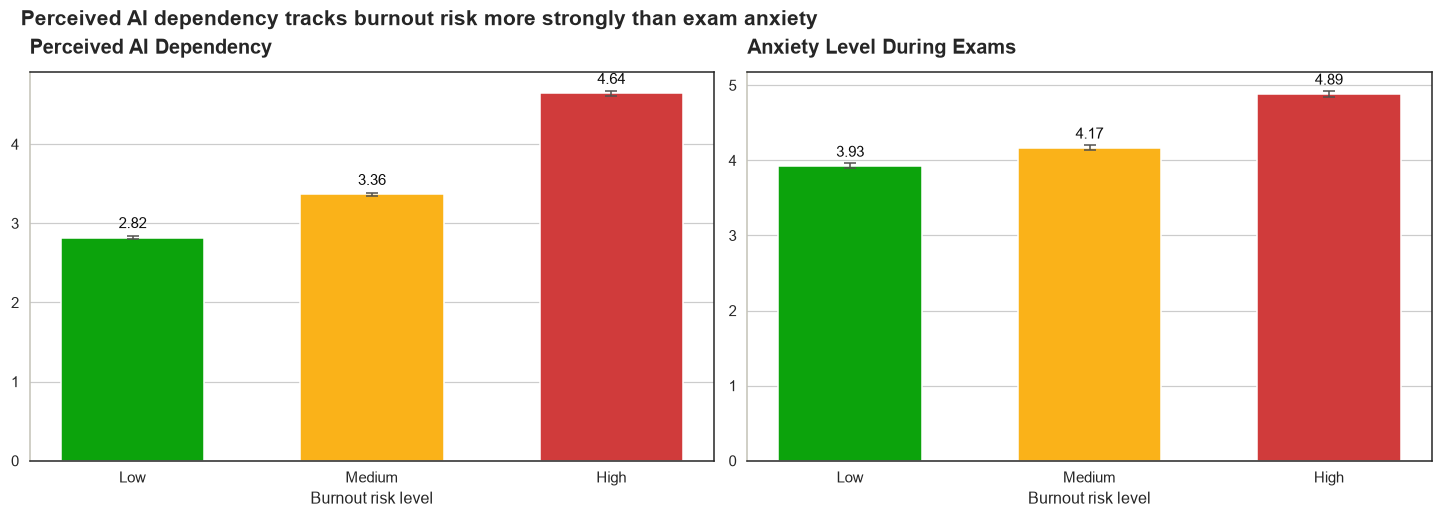

In [9]:
risk_order = ["Low", "Medium", "High"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), constrained_layout=True)
for ax, col in zip(axes, ["Perceived_AI_Dependency", "Anxiety_Level_During_Exams"]):
    means = df.groupby("Burnout_Risk_Level")[col].mean().reindex(risk_order)
    sds = df.groupby("Burnout_Risk_Level")[col].std().reindex(risk_order)
    ns = df.groupby("Burnout_Risk_Level")[col].count().reindex(risk_order)
    ci = 1.96 * sds / np.sqrt(ns)
    ax.bar(risk_order, means.values, yerr=ci.values, width=0.6,
           color=[RISK_COLORS[r] for r in risk_order],
           error_kw=dict(ecolor=INK_SOFT, capsize=4, lw=1))
    for i, v in enumerate(means.values):
        ax.text(i, v + 0.12, f"{v:.2f}", ha="center", fontsize=10, color=INK)
    ax.set_title(col.replace("_", " ")); ax.set_xlabel("Burnout risk level")
    style_axis(ax)
fig.suptitle("Perceived AI dependency tracks burnout risk more strongly than exam anxiety",
             fontsize=13.5, fontweight="bold", x=0.01, ha="left")
plt.show()

**Reading it.** Perceived AI dependency climbs sharply from low- to
high-burnout students, a steeper gradient than exam anxiety shows. Dependency -
a *pattern of use*, again, rather than volume - is the wellbeing signal to watch.

## 7. Correlation structure

Finally, the linear correlation matrix over all numeric variables, on the
blue-to-red diverging ramp about a neutral zero. This is a map, not a test:
Notebook 03 supplies the inference.

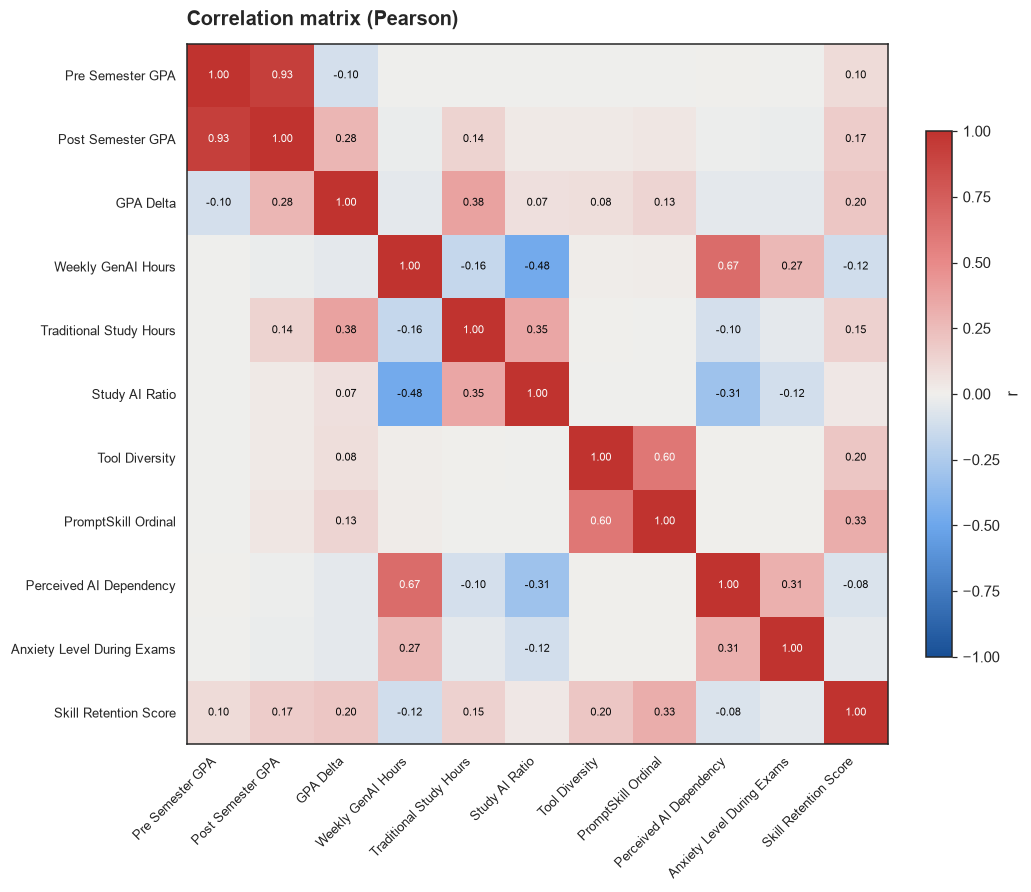

In [10]:
num = ["Pre_Semester_GPA", "Post_Semester_GPA", "GPA_Delta", "Weekly_GenAI_Hours",
       "Traditional_Study_Hours", "Study_AI_Ratio", "Tool_Diversity", "PromptSkill_Ordinal",
       "Perceived_AI_Dependency", "Anxiety_Level_During_Exams", "Skill_Retention_Score"]
corr = df[num].corr()
fig, ax = plt.subplots(figsize=(9.5, 8), constrained_layout=True)
im = ax.imshow(corr.values, cmap=DIVERGING, vmin=-1, vmax=1)
labels = [n.replace("_", " ") for n in num]
ax.set_xticks(range(len(num))); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8.5)
ax.set_yticks(range(len(num))); ax.set_yticklabels(labels, fontsize=8.5)
for i in range(len(num)):
    for j in range(len(num)):
        v = corr.values[i, j]
        if abs(v) >= 0.05:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                    color=SURFACE if abs(v) > 0.55 else INK)
ax.set_title("Correlation matrix (Pearson)")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.75, label="r")
plt.show()

**Reading it.** The strongest correlate of grade improvement is traditional
study hours (positive), reinforcing Section 5. Skill retention correlates
positively with prompt skill and tool diversity and negatively with weekly GenAI
hours and dependency - the inverted-U and offloading stories in one column.
`df["_gen_bin"]` / `_std_bin` were scratch columns; the persisted table is
unchanged.

## Summary of the exploratory picture

1. Demographic differences (discipline, year) are small.
2. Intensity relates to skill retention through an **inverted-U** - a moderate-use
   optimum (RQ1).
3. **Purpose** separates outcomes more than amount; cognitive offloading is the
   weakest pattern (RQ2).
4. **Prompt skill** lifts retention within every band and protects heavy users
   (RQ3).
5. Grade improvement is driven by **study time**, with GenAI complementary (RQ4).
6. **Perceived dependency** is the wellbeing signal tied to burnout (RQ5).

These are visual patterns. **Notebook 03** now tests the load-bearing ones -
the inverted-U and the use-case differences - with formal statistics.